In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [ ]:
# 2. Load Dataset
data = pd.read_csv("Water Quality.csv")
print("Dataset shape:", data.shape)
print("\nDataset info:")
print(data.info())
print("\nFirst 5 rows:")
print(data.head())

Dataset shape: (10800, 4)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ec value(ms/cm)  10800 non-null  float64
 1    pH Value        10800 non-null  float64
 2   TDS Value(ppm)   10800 non-null  int64  
 3   Label            10800 non-null  int64  
dtypes: float64(2), int64(2)
memory usage: 337.6 KB
None

First 5 rows:
   Ec value(ms/cm)   pH Value  TDS Value(ppm)  Label
0             1.72       7.54             129      1
1             1.72       7.53             129      1
2             1.72       7.54             129      1
3             1.50       7.55             129      1
4             1.72       7.52             129      1


In [ ]:
# 3. Separate features (X) and labels (y)

# The label column is 'Label' as seen from the head of the dataframe
label_col = 'Label'

print(f"Detected label column: {label_col}")

X = data.drop(label_col, axis=1)
y = data[label_col]

Detected label column: Label


In [ ]:
# 4. Encode labels (tap water, soap water, drain water → 0/1/2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# 5. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [ ]:
# 7. Build Deep Learning Model
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax")   # 3 classes: tap, soap, drain
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,691 (10.51 KB)

 Trainable params: 2,563 (10.01 KB)

 Non-trainable params: 128 (512.00 B)

In [34]:
# 8. Train Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9883 - loss: 0.0493 - val_accuracy: 0.9931 - val_loss: 0.0255
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9845 - loss: 0.0560 - val_accuracy: 0.9959 - val_loss: 0.0230
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9895 - loss: 0.0422 - val_accuracy: 0.9959 - val_loss: 0.0203
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9892 - loss: 0.0465 - val_accuracy: 0.9959 - val_loss: 0.0214
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9903 - loss: 0.0376 - val_accuracy: 0.9959 - val_loss: 0.0242
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9897 - loss: 0.0412 - val_accuracy: 0.9942 - val_loss: 0.0235
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9923 - loss: 0.0383 - val_accuracy: 0.9965 - val_loss: 0.0212
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9909 - loss: 0.0375 - val_ac

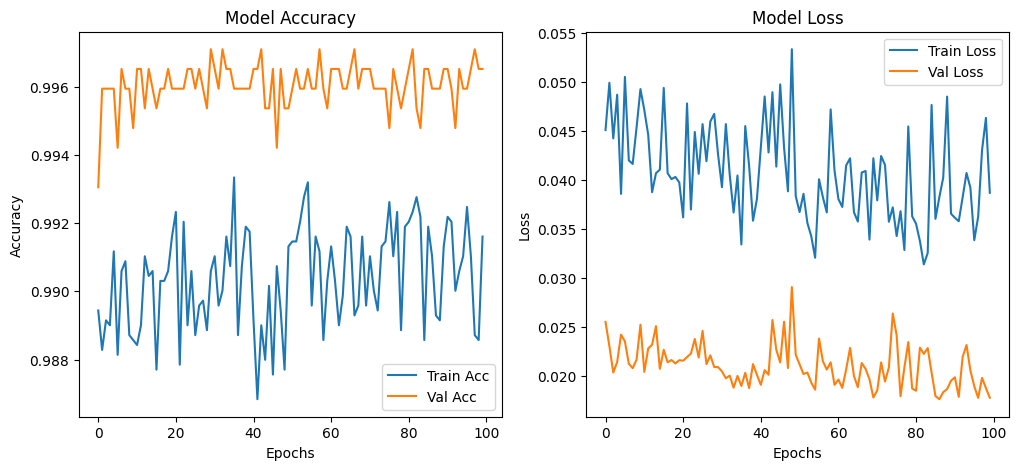

In [35]:
# 9. Plot Accuracy & Loss
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [36]:
# 10. Evaluate on Test Data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get the original class names from the LabelEncoder and ensure they are strings
target_names = [str(name) for name in le.inverse_transform([0, 1, 2])]

print("Test Accuracy:", accuracy_score(y_test, y_pred_classes))
print("\nClassification Report:\n", classification_report(y_test, y_pred_classes, target_names=target_names))

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test Accuracy: 0.9953703703703703

Classification Report:
               precision    recall  f1-score   support

           1       0.99      1.00      0.99       720
           2       1.00      0.99      0.99       720
           3       1.00      1.00      1.00       720

    accuracy                           1.00      2160
   macro avg       1.00      1.00      1.00      2160
weighted avg       1.00      1.00      1.00      2160



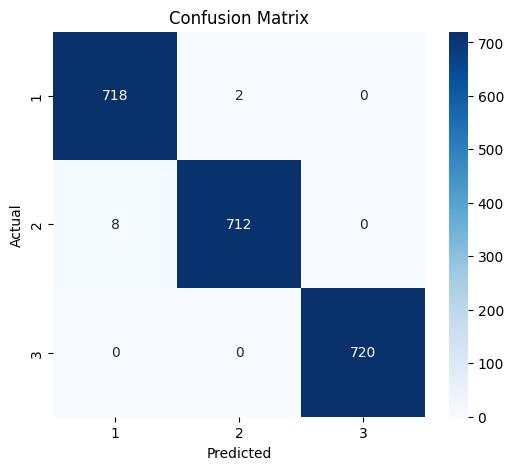

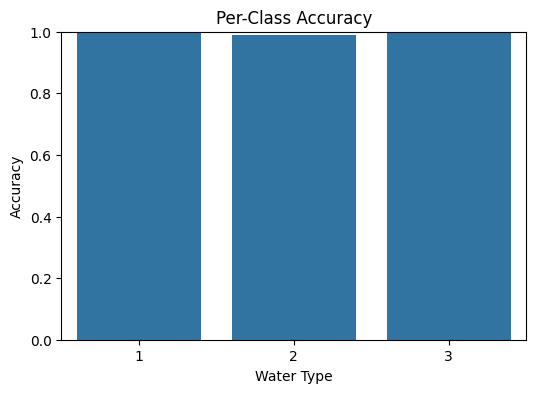

In [37]:
# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 11b. Per-Class Accuracy Bar Chart
# ================================
cm = confusion_matrix(y_test, y_pred_classes)
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(6,4))
sns.barplot(x=le.classes_, y=class_accuracy)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.xlabel("Water Type")
plt.title("Per-Class Accuracy")
plt.show()

In [38]:
# 12. Single-Sample Prediction Demo (Manual Example)
# Example new sensor readings: [EC, pH, TDS]
new_sample = np.array([[400, 7.2, 120]])   # Example values
new_sample_scaled = scaler.transform(new_sample)

prediction = model.predict(new_sample_scaled)
predicted_class = le.inverse_transform([np.argmax(prediction)])

print("\n--- Single Sample Prediction Demo ---")
print("Input sensor values (EC, pH, TDS):", new_sample[0])
print("Predicted Water Type:", predicted_class[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

--- Single Sample Prediction Demo ---
Input sensor values (EC, pH, TDS): [400.    7.2 120. ]
Predicted Water Type: 3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [39]:
# 13. Random Sample Prediction from Dataset
idx = random.randint(0, len(X_test)-1)

random_sample = X_test[idx].reshape(1, -1)
true_label = le.inverse_transform([y_test[idx]])

prediction = model.predict(random_sample)
predicted_class = le.inverse_transform([np.argmax(prediction)])

print("\n--- Random Sample Prediction Demo ---")
print("Sensor values (scaled):", X_test[idx])
print("Actual Water Type:", true_label[0])
print("Predicted Water Type:", predicted_class[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

--- Random Sample Prediction Demo ---
Sensor values (scaled): [-0.64242975 -0.58581218 -0.58094576]
Actual Water Type: 2
Predicted Water Type: 2
